In [1]:
##Final Capstone project
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('C:/Dinesh_Masters/Capstone/Finalcapstone'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

C:/Dinesh_Masters/Capstone/Finalcapstone\nasa-cmapss-turbofan-engine.ipynb
C:/Dinesh_Masters/Capstone/Finalcapstone\readme.txt
C:/Dinesh_Masters/Capstone/Finalcapstone\RUL_FD001.txt
C:/Dinesh_Masters/Capstone/Finalcapstone\RUL_FD002.txt
C:/Dinesh_Masters/Capstone/Finalcapstone\RUL_FD003.txt
C:/Dinesh_Masters/Capstone/Finalcapstone\RUL_FD004.txt
C:/Dinesh_Masters/Capstone/Finalcapstone\test_FD001.txt
C:/Dinesh_Masters/Capstone/Finalcapstone\test_FD002.txt
C:/Dinesh_Masters/Capstone/Finalcapstone\test_FD003.txt
C:/Dinesh_Masters/Capstone/Finalcapstone\test_FD004.txt
C:/Dinesh_Masters/Capstone/Finalcapstone\train_FD001.txt
C:/Dinesh_Masters/Capstone/Finalcapstone\train_FD002.txt
C:/Dinesh_Masters/Capstone/Finalcapstone\train_FD003.txt
C:/Dinesh_Masters/Capstone/Finalcapstone\train_FD004.txt


# Imports + Loader (CMAPSS)

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

def load_cmapss_split(data_root, fd="FD001"):
    train_path = f"{data_root}/train_{fd}.txt"
    test_path  = f"{data_root}/test_{fd}.txt"
    rul_path   = f"{data_root}/RUL_{fd}.txt"

    train = pd.read_csv(train_path, sep=r"\s+", header=None, engine="python")
    test  = pd.read_csv(test_path,  sep=r"\s+", header=None, engine="python")
    rul   = pd.read_csv(rul_path,   sep=r"\s+", header=None, engine="python")

    cols = ["unit_id", "cycle"] + [f"op_setting_{i}" for i in range(1, 4)] + [f"s{i}" for i in range(1, 22)]
    train.columns = cols
    test.columns  = cols
    rul.columns   = ["RUL_true"]

    return train, test, rul

def add_train_rul(train_df):
    df = train_df.copy()
    df["RUL"] = df.groupby("unit_id")["cycle"].transform("max") - df["cycle"]
    return df

def add_test_rul(test_df, rul_df):
    df = test_df.copy()
    last_cycle = df.groupby("unit_id")["cycle"].max().rename("last_cycle")
    tmp = last_cycle.to_frame().join(rul_df.reset_index(drop=True))
    tmp["max_cycle_est"] = tmp["last_cycle"] + tmp["RUL_true"].values
    df = df.join(tmp["max_cycle_est"], on="unit_id")
    df["RUL"] = df["max_cycle_est"] - df["cycle"]
    df.drop(columns=["max_cycle_est"], inplace=True)
    return df

In [3]:
DATA_ROOT = "C:/Dinesh_Masters/Capstone/Finalcapstone"

# Load Dataset

In [4]:
FD = "FD001"
train_raw, test_raw, rul_true = load_cmapss_split(DATA_ROOT, FD)
print(train_raw.shape, test_raw.shape, rul_true.shape)
train_raw.head()

(20631, 26) (13096, 26) (100, 1)


,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


# Quick Data Audit (Quality + Types + Missing)

In [5]:
FD = "FD001"

train_raw, test_raw, rul_true = load_cmapss_split(DATA_ROOT, FD)
train = add_train_rul(train_raw)
test  = add_test_rul(test_raw, rul_true)

print(train.shape, test.shape)

(20631, 27) (13096, 27)


In [6]:
def audit(df, name="df"):
    print(f"\n### {name}")
    display(df.head(5))
    print("\ninfo:")
    df.info()
    print("\nmissing (top 10):")
    display(df.isna().sum().sort_values(ascending=False).head(10))
    print("\nduplicates:", df.duplicated().sum())

audit(train, "Train (with RUL)")
audit(test,  "Test (with RUL)")


### Train (with RUL)


,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187



info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 27 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   unit_id       20631 non-null  int64  
 1   cycle         20631 non-null  int64  
 2   op_setting_1  20631 non-null  float64
 3   op_setting_2  20631 non-null  float64
 4   op_setting_3  20631 non-null  float64
 5   s1            20631 non-null  float64
 6   s2            20631 non-null  float64
 7   s3            20631 non-null  float64
 8   s4            20631 non-null  float64
 9   s5            20631 non-null  float64
 10  s6            20631 non-null  float64
 11  s7            20631 non-null  float64
 12  s8            20631 non-null  float64
 13  s9            20631 non-null  float64
 14  s10           20631 non-null  float64
 15  s11           20631 non-null  float64
 16  s12           20631 non-null  float64
 17  s13           20631 non-null  float64
 18  s14           20631

unit_id    0
s10        0
s21        0
s20        0
s19        0
s18        0
s17        0
s16        0
s15        0
s14        0
dtype: int64


duplicates: 0

### Test (with RUL)


,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,RUL
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735,128.0
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916,127.0
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166,126.0
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737,125.0
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130,124.0



info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13096 entries, 0 to 13095
Data columns (total 27 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   unit_id       13096 non-null  int64  
 1   cycle         13096 non-null  int64  
 2   op_setting_1  13096 non-null  float64
 3   op_setting_2  13096 non-null  float64
 4   op_setting_3  13096 non-null  float64
 5   s1            13096 non-null  float64
 6   s2            13096 non-null  float64
 7   s3            13096 non-null  float64
 8   s4            13096 non-null  float64
 9   s5            13096 non-null  float64
 10  s6            13096 non-null  float64
 11  s7            13096 non-null  float64
 12  s8            13096 non-null  float64
 13  s9            13096 non-null  float64
 14  s10           13096 non-null  float64
 15  s11           13096 non-null  float64
 16  s12           13096 non-null  float64
 17  s13           13096 non-null  float64
 18  s14           13096

RUL    198
s10      0
s21      0
s20      0
s19      0
s18      0
s17      0
s16      0
s15      0
s14      0
dtype: int64


duplicates: 0


# 3) Engine-level Summary (lifetimes + rows)

In [7]:
train_eng = train.groupby("unit_id").agg(
    max_cycle=("cycle","max"),
    min_cycle=("cycle","min"),
    n_rows=("cycle","count"),
    start_rul=("RUL","max"),
    end_rul=("RUL","min"),
).reset_index()

test_eng = test.groupby("unit_id").agg(
    max_cycle=("cycle","max"),
    min_cycle=("cycle","min"),
    n_rows=("cycle","count"),
    start_rul=("RUL","max"),
    end_rul=("RUL","min"),
).reset_index()

display(train_eng.describe().T)
display(test_eng.describe().T)

,count,mean,std,min,25%,50%,75%,max
unit_id,100.0,50.50,29.011492,1.0,25.75,50.5,75.25,100.0
max_cycle,100.0,206.31,46.342749,128.0,177.00,199.0,229.25,362.0
min_cycle,100.0,1.00,0.000000,1.0,1.00,1.0,1.00,1.0
n_rows,100.0,206.31,46.342749,128.0,177.00,199.0,229.25,362.0
start_rul,100.0,205.31,46.342749,127.0,176.00,198.0,228.25,361.0
end_rul,100.0,0.00,0.000000,0.0,0.00,0.0,0.00,0.0


,count,mean,std,min,25%,50%,75%,max
unit_id,100.0,50.500000,29.011492,1.0,25.75,50.5,75.25,100.0
max_cycle,100.0,130.960000,53.593479,31.0,88.75,133.5,164.25,303.0
min_cycle,100.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
n_rows,100.0,130.960000,53.593479,31.0,88.75,133.5,164.25,303.0
start_rul,99.0,204.434343,65.006618,56.0,150.50,204.0,253.50,381.0
end_rul,99.0,75.151515,41.813816,7.0,31.50,85.0,112.00,145.0


# 4) Engine Lifetime Distribution (Train)

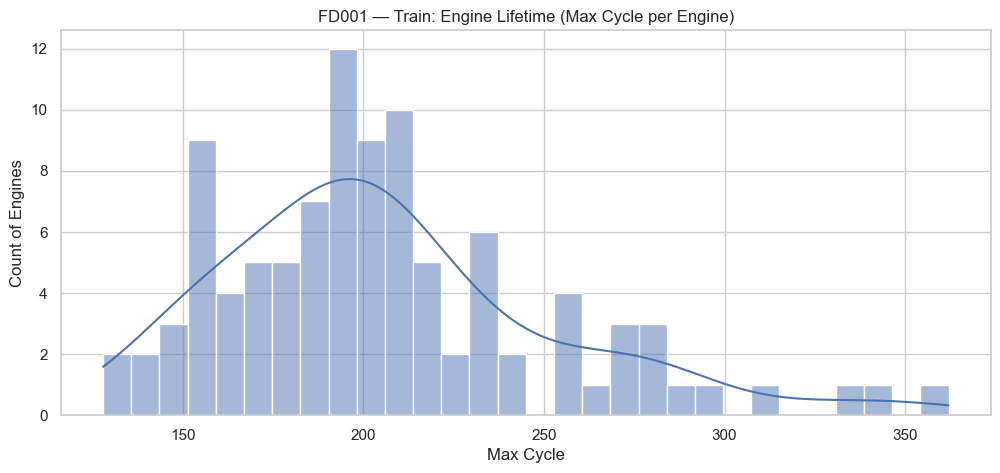

In [8]:
plt.figure()
sns.histplot(train_eng["max_cycle"], bins=30, kde=True)
plt.title(f"{FD} — Train: Engine Lifetime (Max Cycle per Engine)")
plt.xlabel("Max Cycle")
plt.ylabel("Count of Engines")
plt.show()

# 5) RUL Distribution (Train)

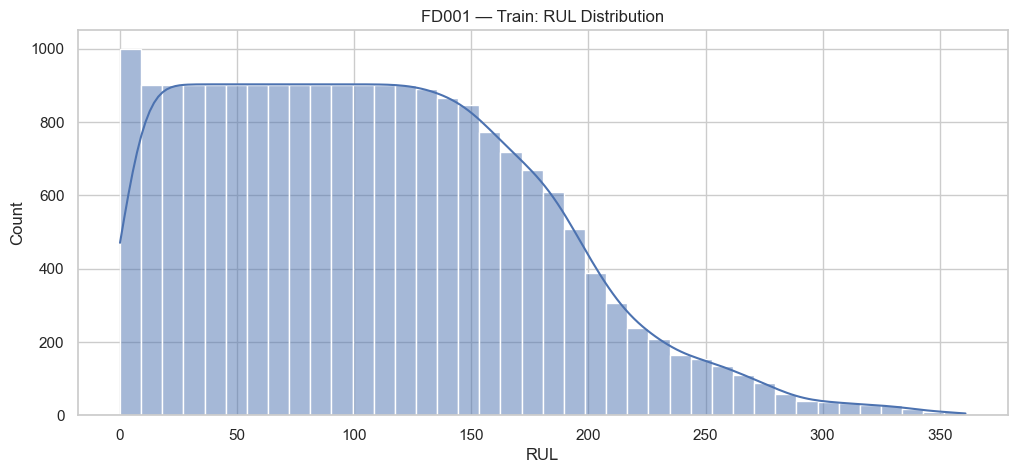

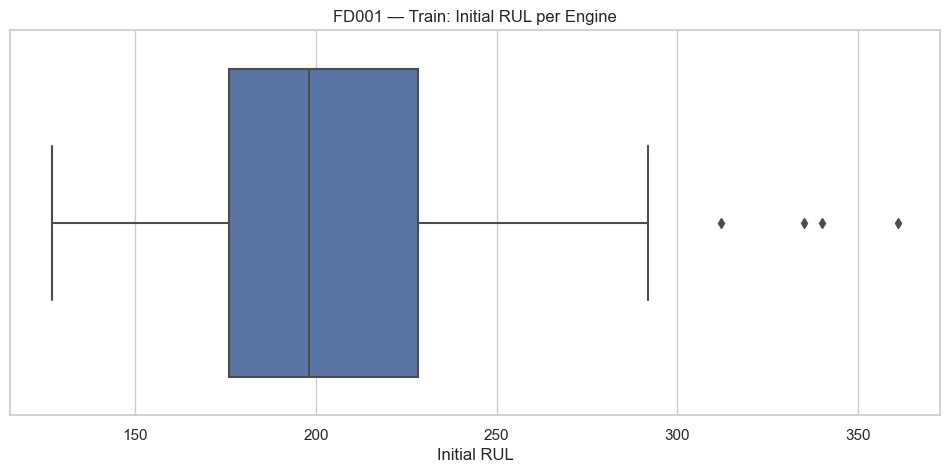

In [9]:
plt.figure()
sns.histplot(train["RUL"], bins=40, kde=True)
plt.title(f"{FD} — Train: RUL Distribution")
plt.xlabel("RUL")
plt.ylabel("Count")
plt.show()

plt.figure()
sns.boxplot(x=train_eng["start_rul"])
plt.title(f"{FD} — Train: Initial RUL per Engine")
plt.xlabel("Initial RUL")
plt.show()

# 6) Feature Groups (Sensors + Operating Settings)

In [10]:
sensor_cols = [c for c in train.columns if c.startswith("s")]
op_cols = [c for c in train.columns if c.startswith("op_setting")]

print("op cols:", op_cols)
print("sensor cols:", len(sensor_cols))
print("first sensors:", sensor_cols[:7])

op cols: ['op_setting_1', 'op_setting_2', 'op_setting_3']
sensor cols: 21
first sensors: ['s1', 's2', 's3', 's4', 's5', 's6', 's7']


# 7) Operating Settings Distributions

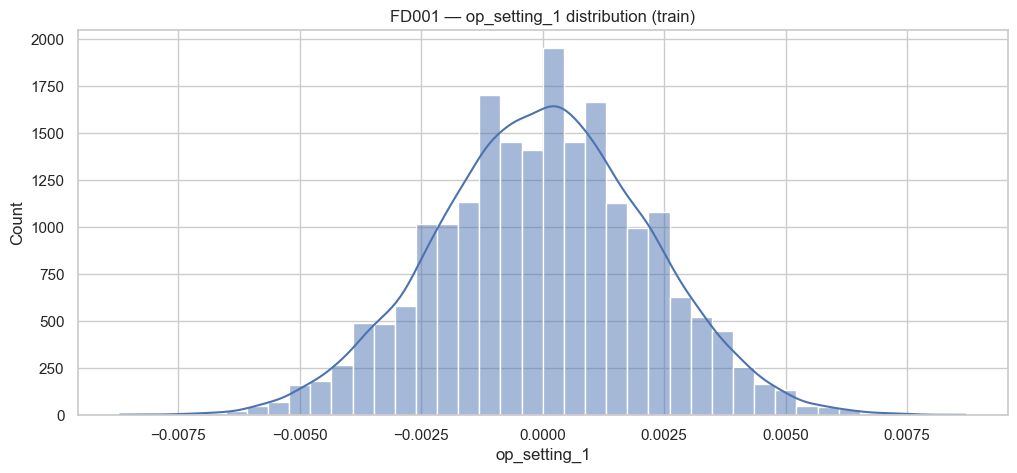

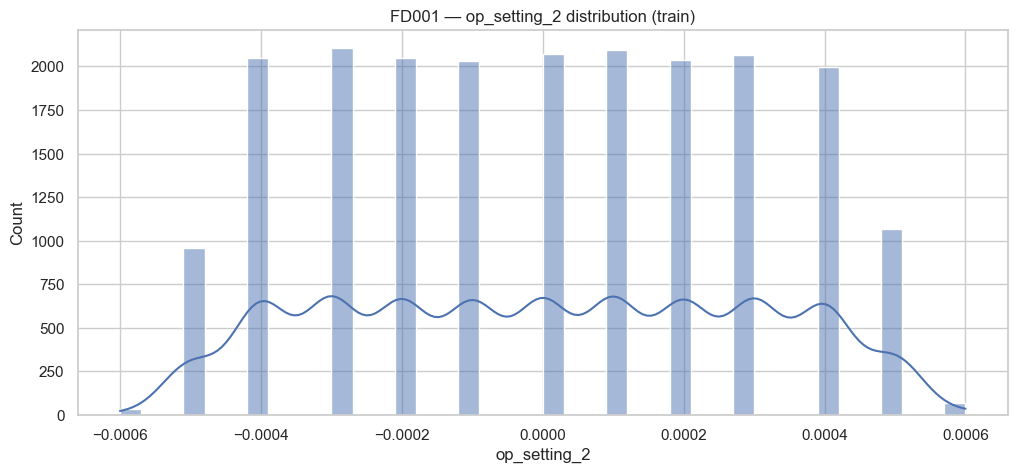

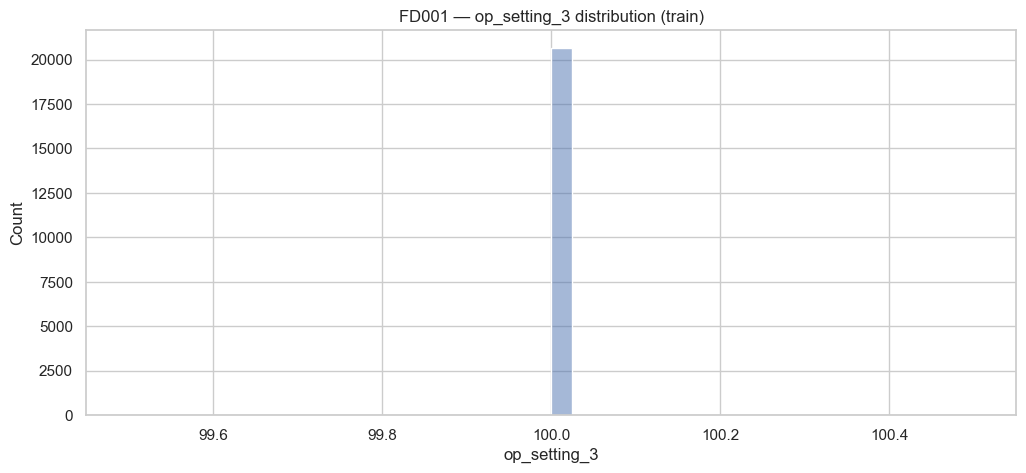

In [11]:
for c in op_cols:
    plt.figure()
    sns.histplot(train[c], bins=40, kde=True)
    plt.title(f"{FD} — {c} distribution (train)")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.show()

# 8) Low-Variance Sensors (Variance Scan)

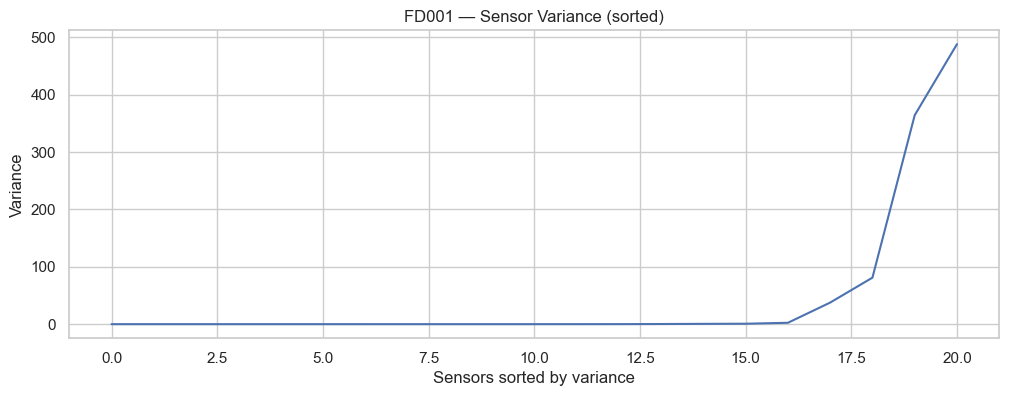

Low-variance sensors: ['s19', 's18', 's16', 's10', 's5', 's1']


In [12]:
sensor_var = train[sensor_cols].var().sort_values()

plt.figure(figsize=(12,4))
sns.lineplot(x=np.arange(len(sensor_var)), y=sensor_var.values)
plt.title(f"{FD} — Sensor Variance (sorted)")
plt.xlabel("Sensors sorted by variance")
plt.ylabel("Variance")
plt.show()

VAR_THRESHOLD = 1e-8
low_var_sensors = sensor_var[sensor_var <= VAR_THRESHOLD].index.tolist()
print("Low-variance sensors:", low_var_sensors)

# 9) Correlation with RUL (Top Signals)

Top features by |corr|: ['s11', 's4', 's12', 's7', 's15', 's21', 's20', 's2', 's17', 's3']


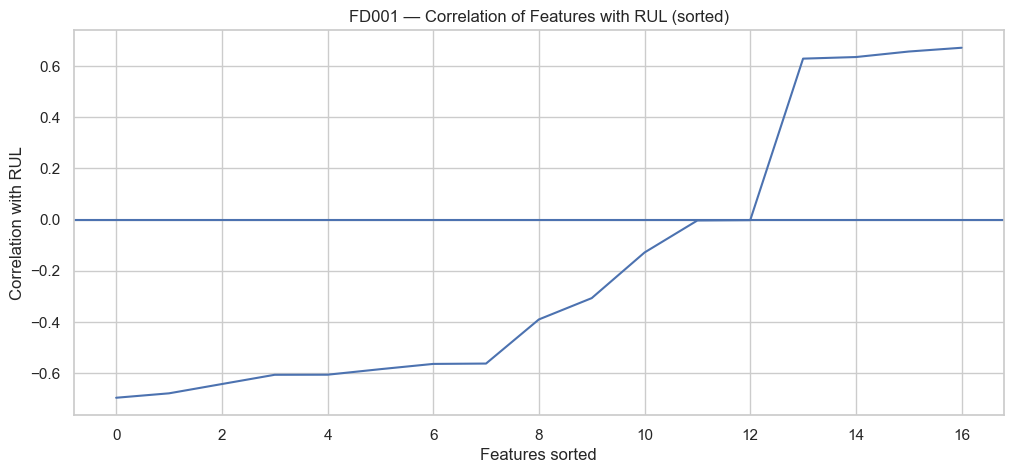

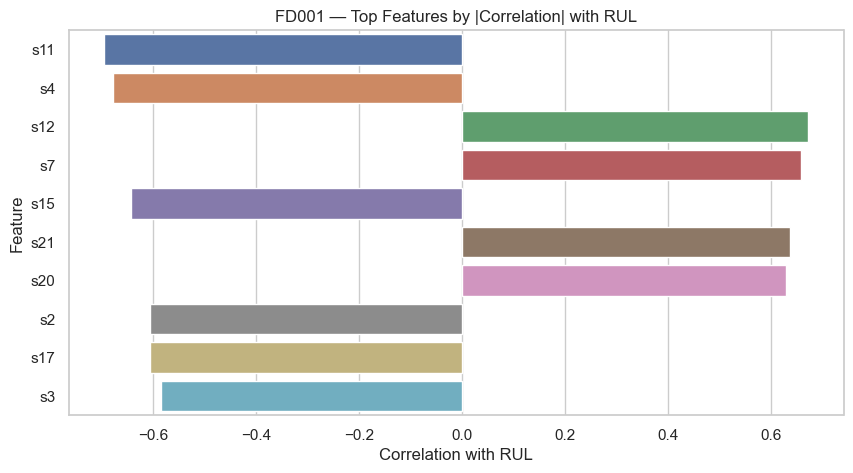

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_numeric = train[sensor_cols + op_cols + ["RUL"]].select_dtypes(include=[np.number])

corr = df_numeric.corr()["RUL"].drop("RUL").sort_values()

top_features = corr.abs().sort_values(ascending=False).head(10).index.tolist()
print("Top features by |corr|:", top_features)

# Line plot
plt.figure(figsize=(12,5))
sns.lineplot(x=np.arange(len(corr)), y=corr.values)
plt.axhline(0)
plt.title(f"{FD} — Correlation of Features with RUL (sorted)")
plt.xlabel("Features sorted")
plt.ylabel("Correlation with RUL")
plt.show()

# Bar plot
plt.figure(figsize=(10,5))
sns.barplot(x=corr.loc[top_features].values, y=top_features, orient="h")
plt.title(f"{FD} — Top Features by |Correlation| with RUL")
plt.xlabel("Correlation with RUL")
plt.ylabel("Feature")
plt.show()

# 10) Feature vs RUL (Scatter using Sampling)

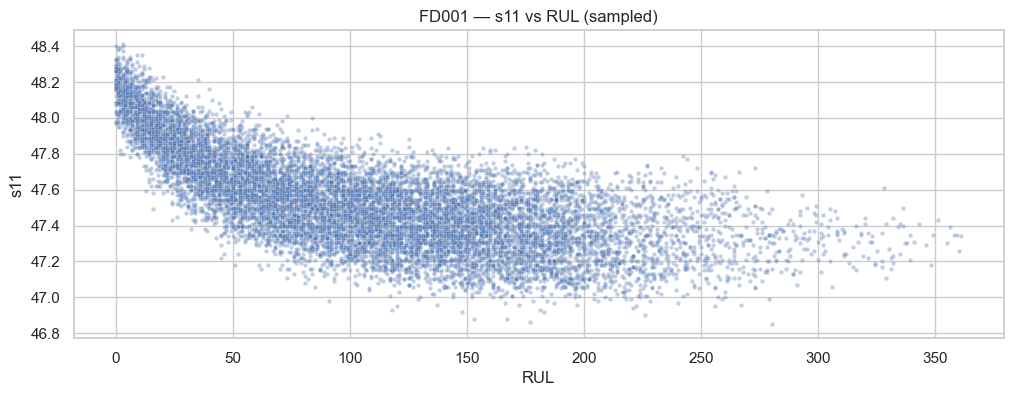

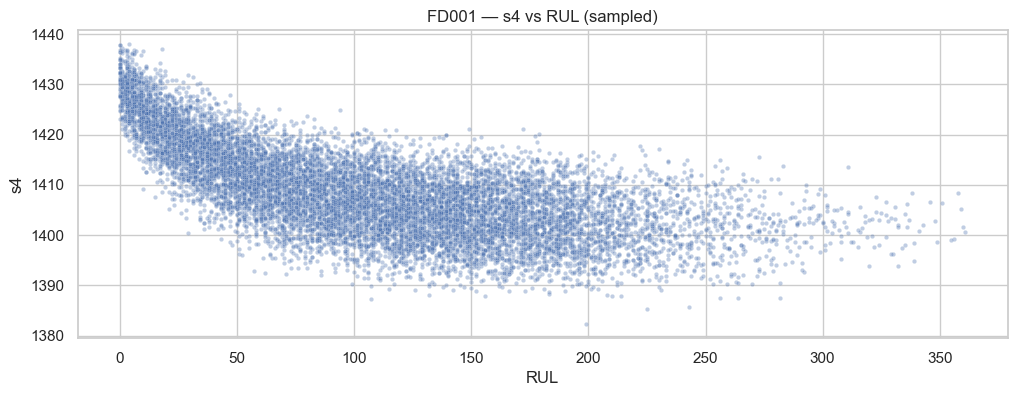

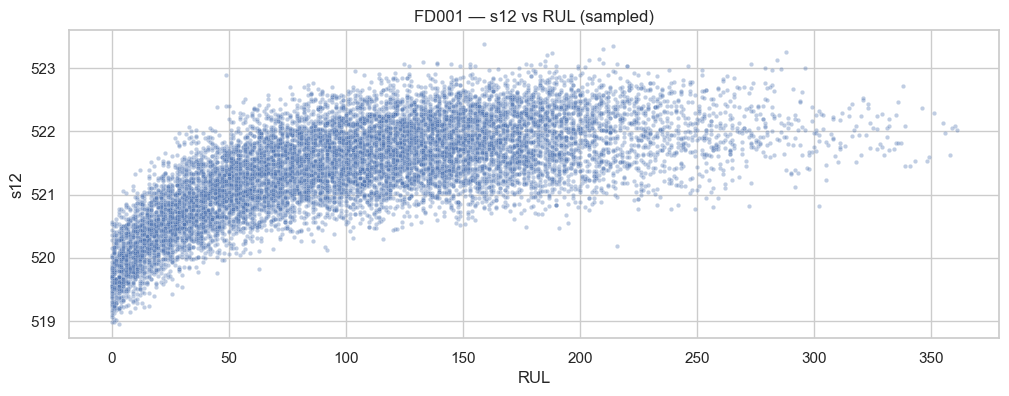

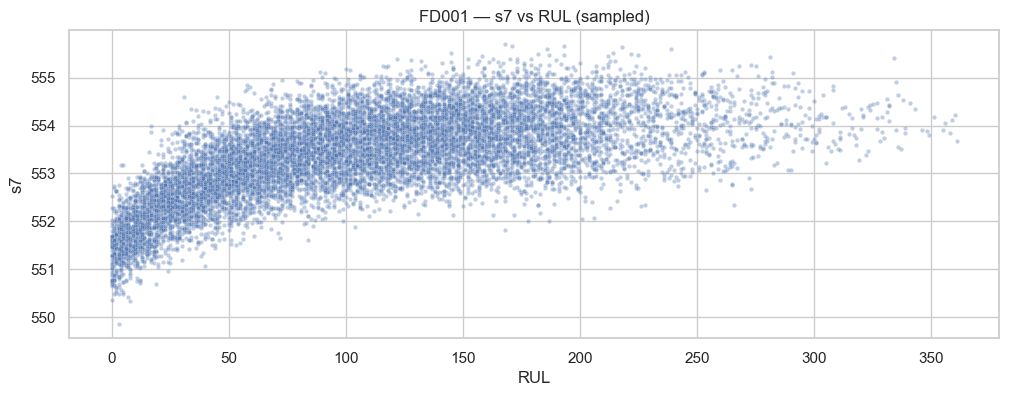

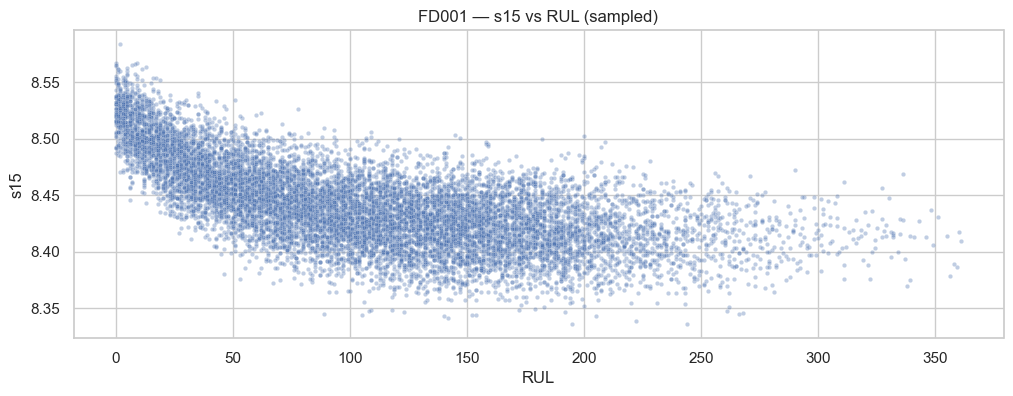

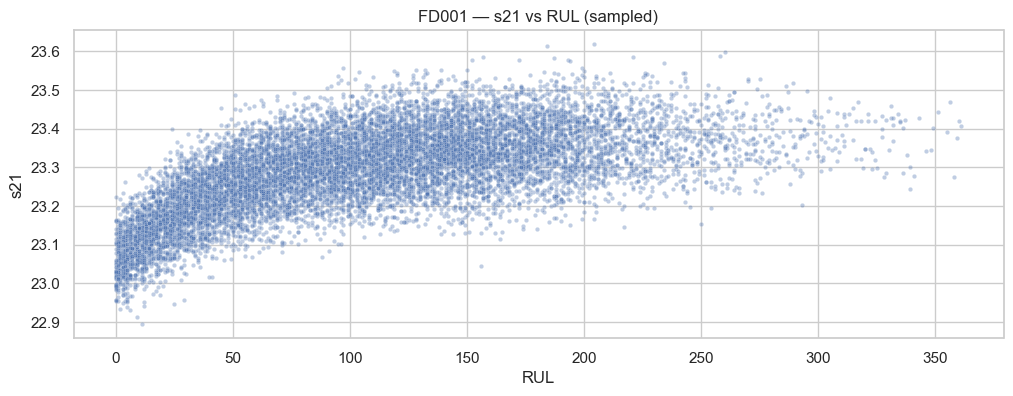

In [32]:
SAMPLE_N = min(12000, len(train))
sample = train[["RUL"] + top_features].sample(SAMPLE_N, random_state=42)

for feat in top_features[:6]:
    plt.figure(figsize=(12,4))
    sns.scatterplot(data=sample, x="RUL", y=feat, s=10, alpha=0.35)
    plt.title(f"{FD} — {feat} vs RUL (sampled)")
    plt.xlabel("RUL")
    plt.ylabel(feat)
    plt.show()

# 11) Feature Trend over RUL Bins (Mean Degradation)

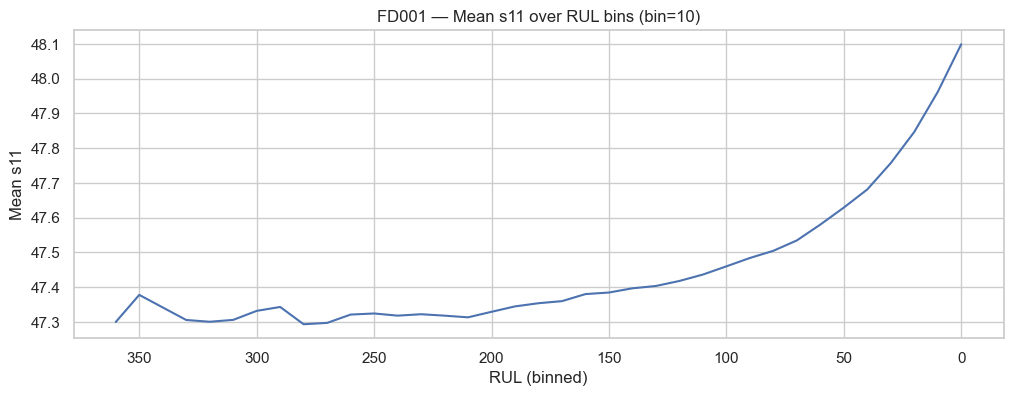

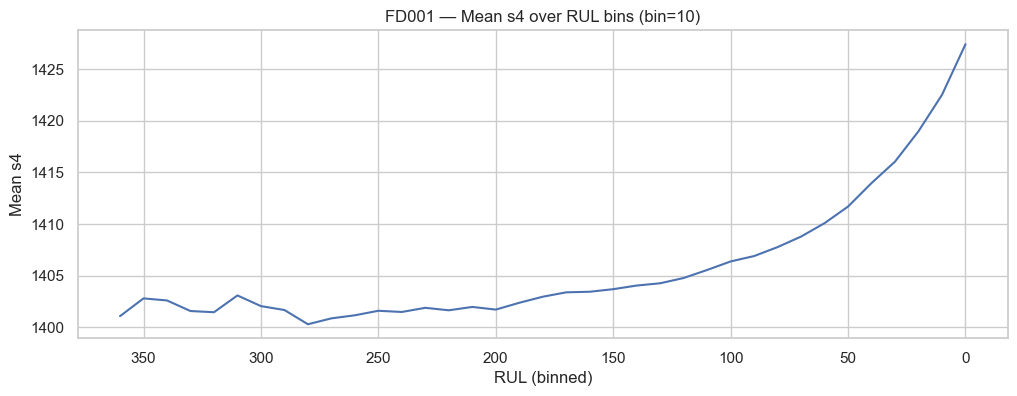

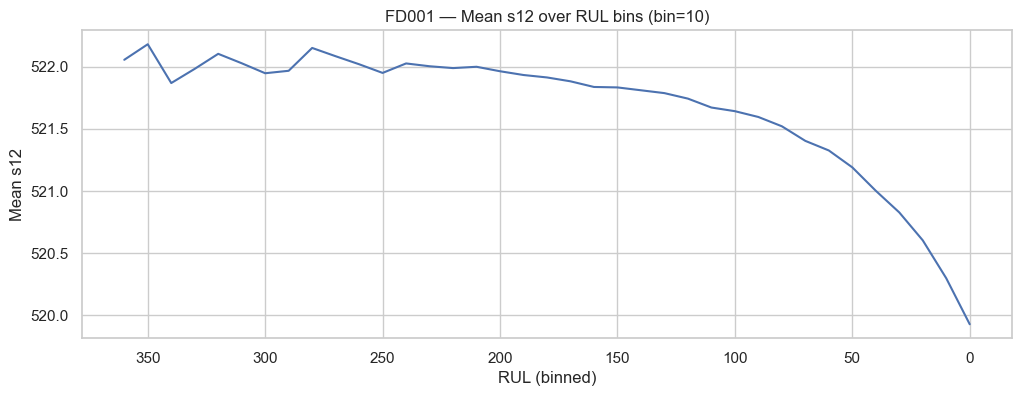

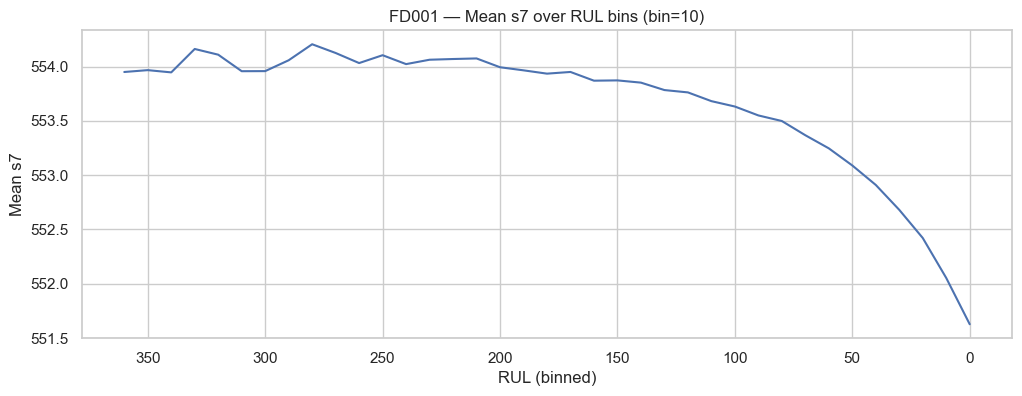

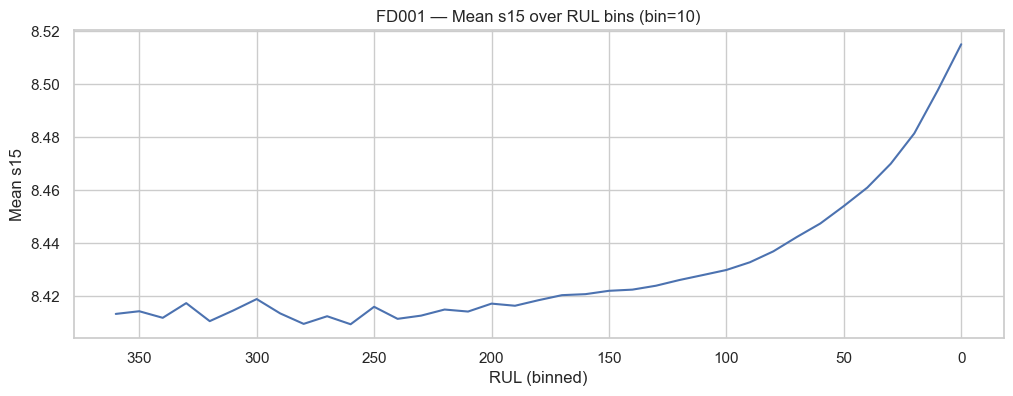

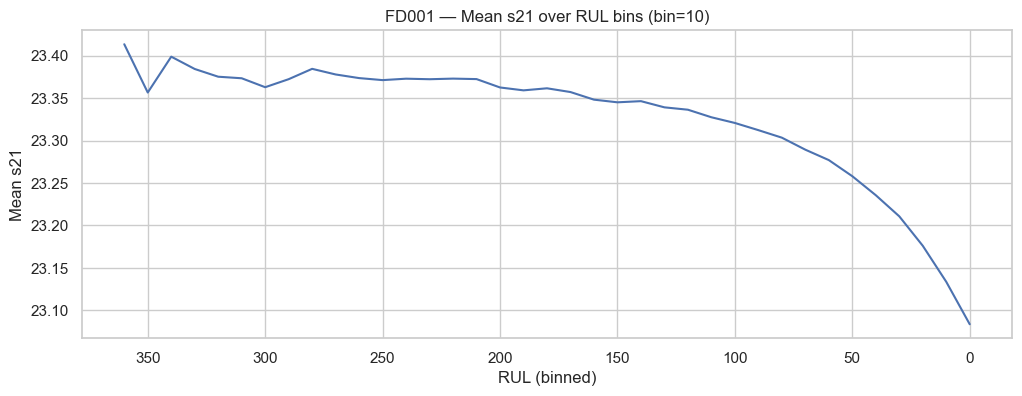

In [33]:
BIN = 10
tmp = train[["RUL"] + top_features[:6]].copy()
tmp["RUL_bin"] = (tmp["RUL"] // BIN) * BIN
agg = tmp.groupby("RUL_bin")[top_features[:6]].mean().reset_index()

for feat in top_features[:6]:
    plt.figure(figsize=(12,4))
    sns.lineplot(data=agg, x="RUL_bin", y=feat)
    plt.gca().invert_xaxis()
    plt.title(f"{FD} — Mean {feat} over RUL bins (bin={BIN})")
    plt.xlabel("RUL (binned)")
    plt.ylabel(f"Mean {feat}")
    plt.show()

# 12) Degradation Profiles per Engine (Time-Series)

Sample engines: [84 54 71]


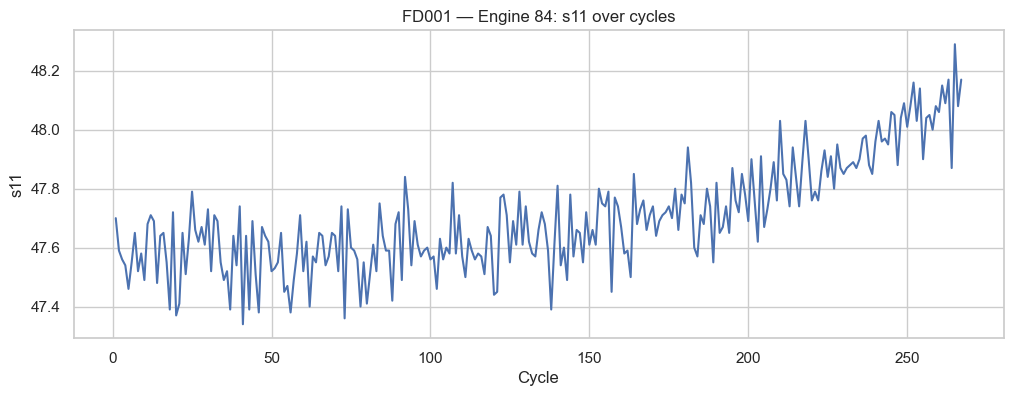

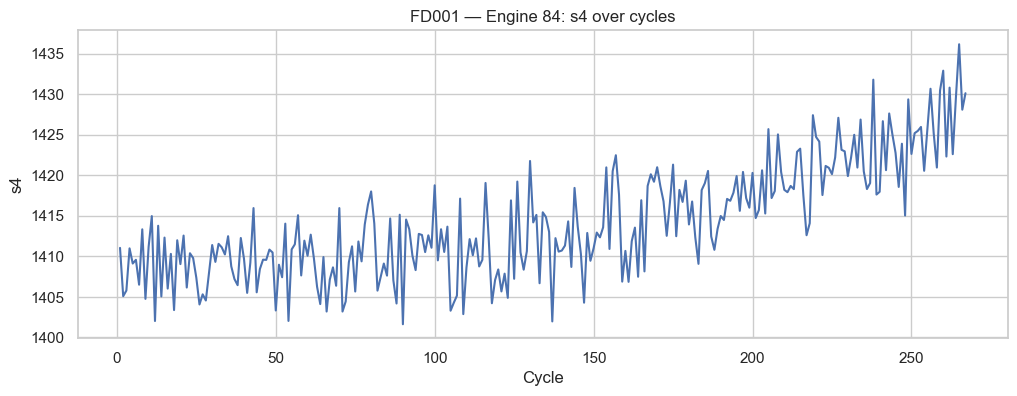

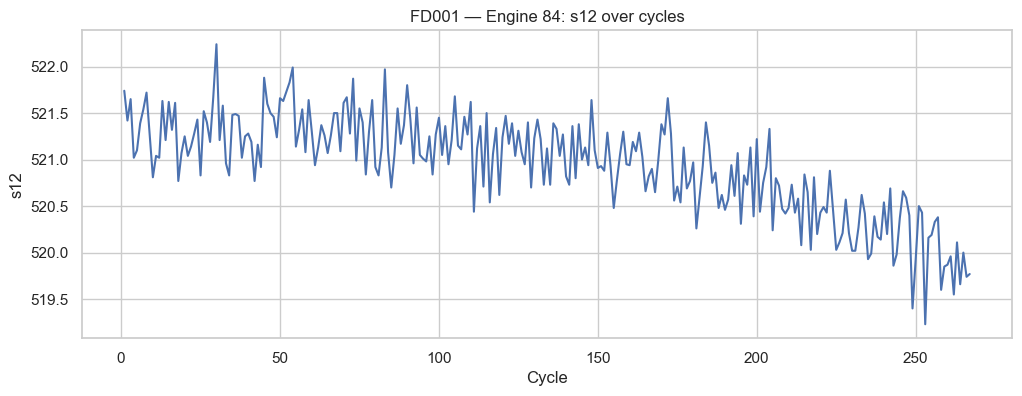

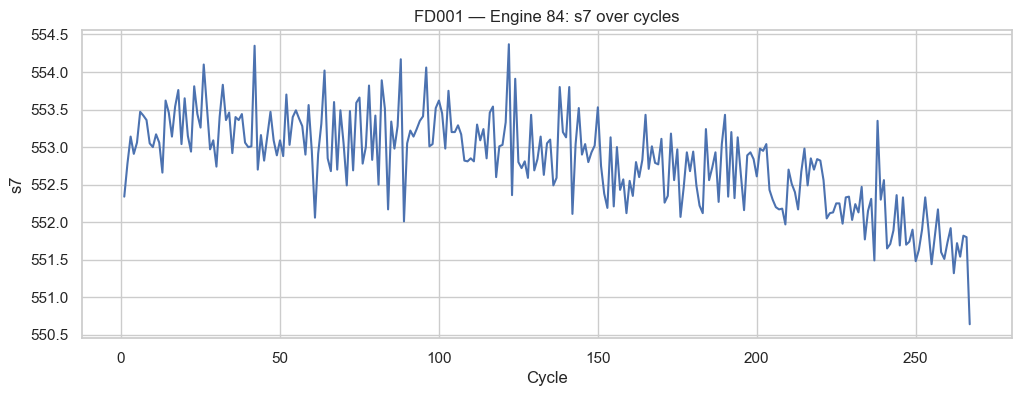

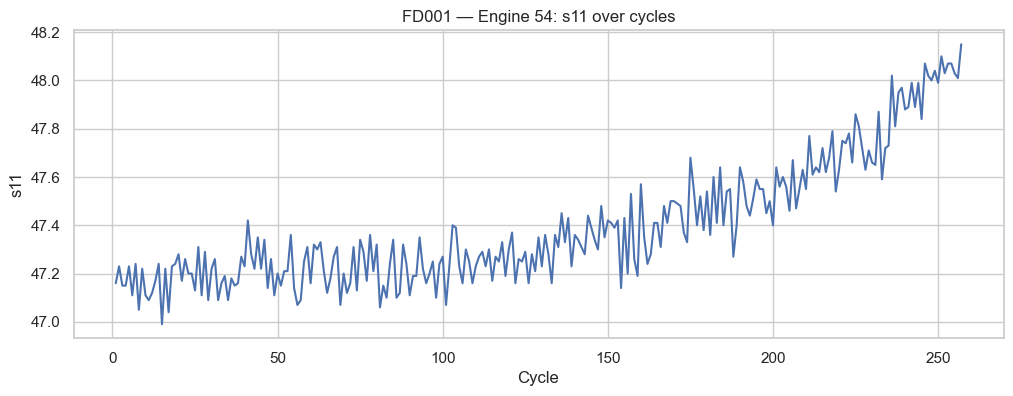

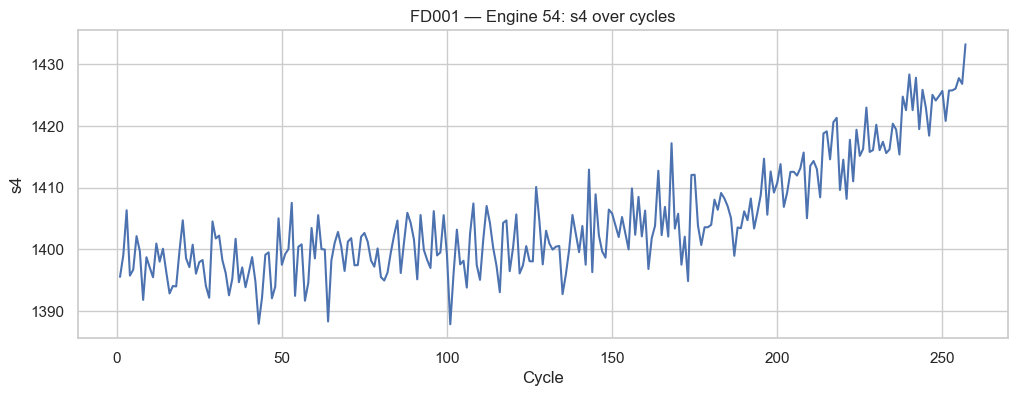

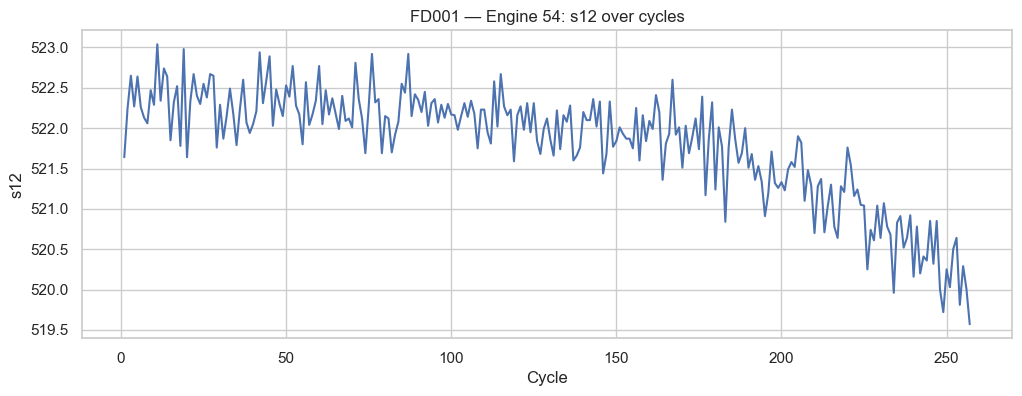

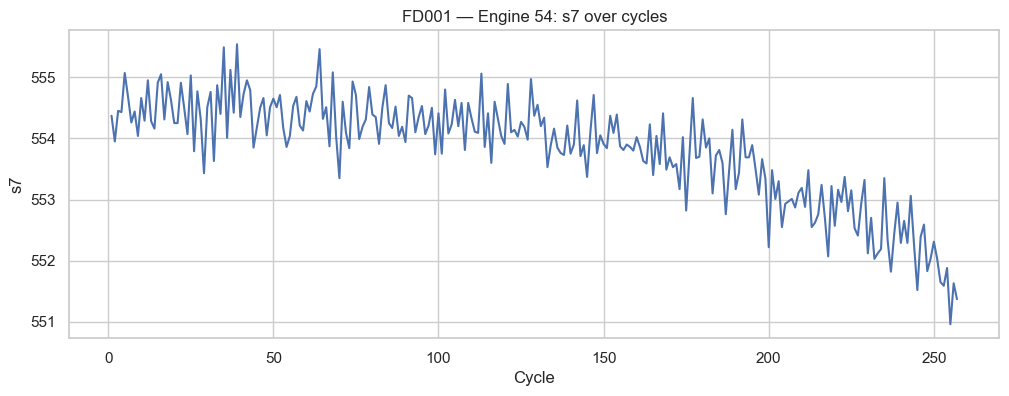

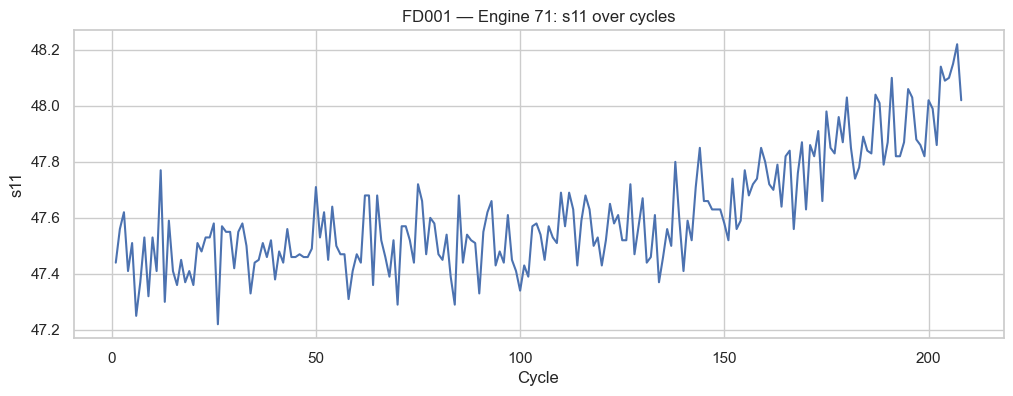

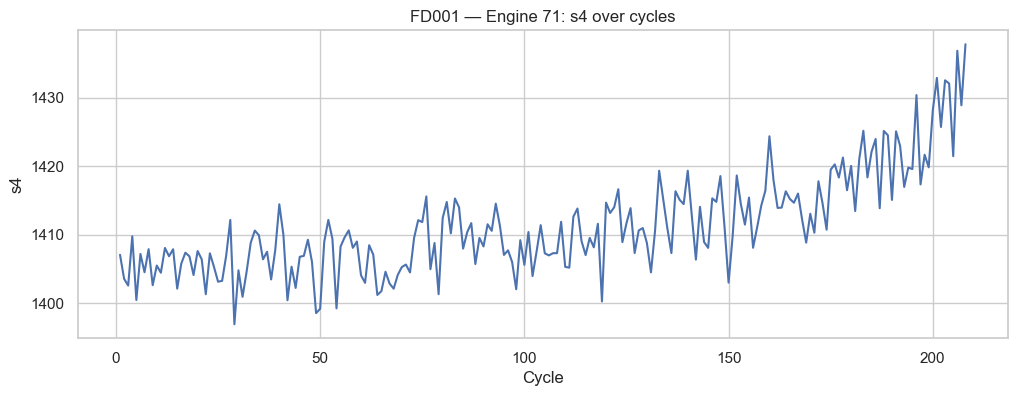

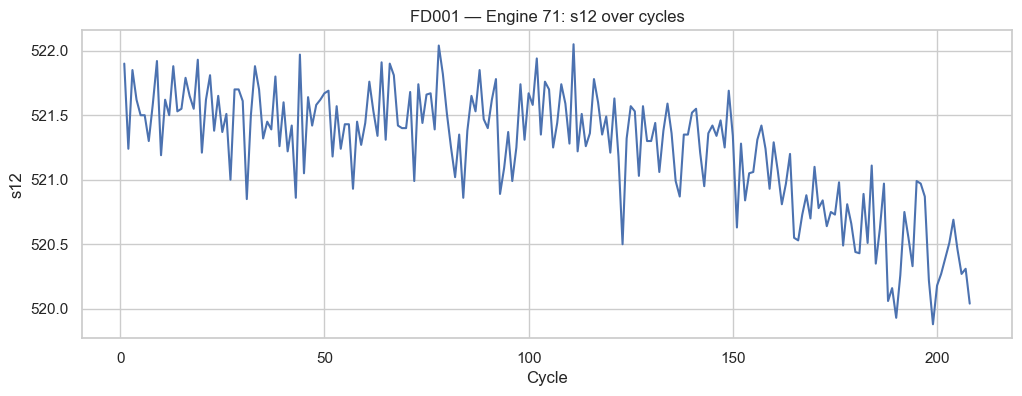

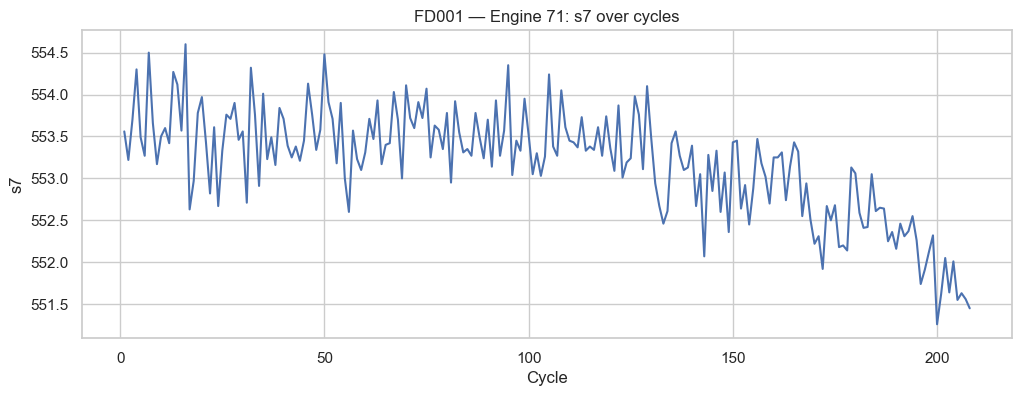

In [34]:
np.random.seed(42)
sample_engines = np.random.choice(train["unit_id"].unique(), size=3, replace=False)
print("Sample engines:", sample_engines)

plot_feats = top_features[:4]

for eng in sample_engines:
    df_e = train[train["unit_id"] == eng].sort_values("cycle")
    for feat in plot_feats:
        plt.figure(figsize=(12,4))
        sns.lineplot(data=df_e, x="cycle", y=feat)
        plt.title(f"{FD} — Engine {eng}: {feat} over cycles")
        plt.xlabel("Cycle")
        plt.ylabel(feat)
        plt.show()

# 13) Normalization per Engine (Z-score)

In [35]:
def per_engine_zscore(df, cols, id_col="unit_id"):
    df2 = df.copy()
    mu = df2.groupby(id_col)[cols].transform("mean")
    sd = df2.groupby(id_col)[cols].transform("std").replace(0, np.nan)
    df2[cols] = (df2[cols] - mu) / sd
    df2[cols] = df2[cols].fillna(0)
    return df2

train_norm = per_engine_zscore(train, sensor_cols + op_cols)
test_norm  = per_engine_zscore(test,  sensor_cols + op_cols)

# 14) Normalized Degradation Visualization (One Engine)

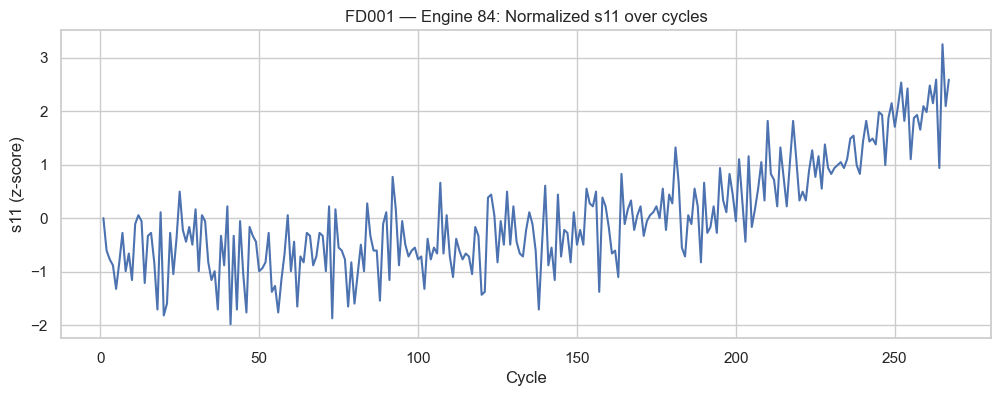

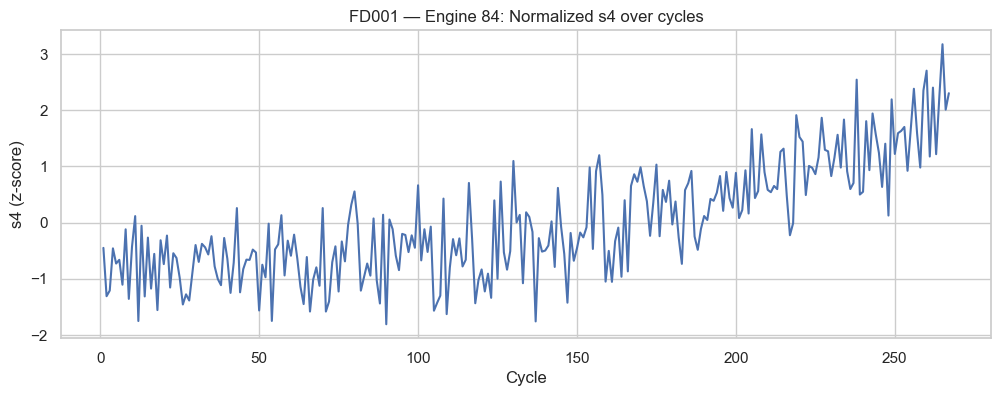

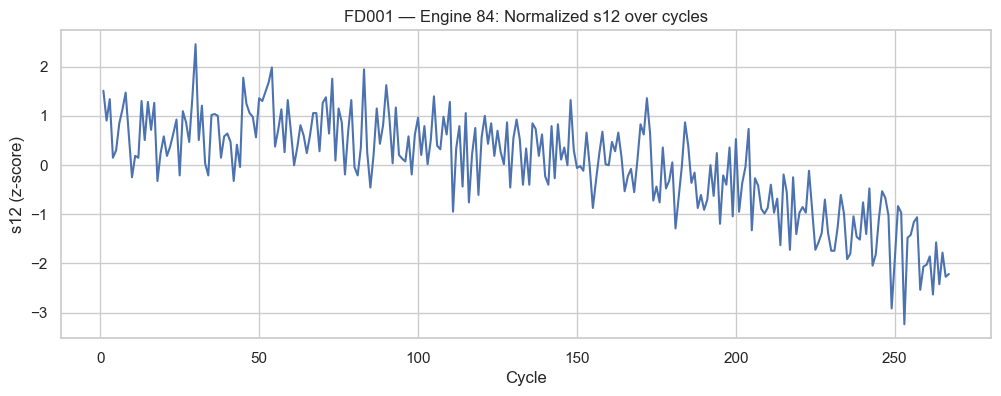

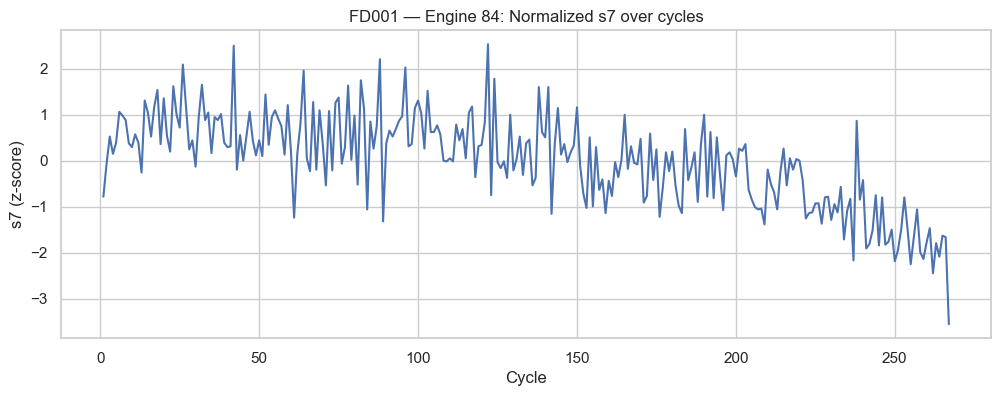

In [36]:
eng = sample_engines[0]
df_e = train_norm[train_norm["unit_id"] == eng].sort_values("cycle")

for feat in plot_feats:
    plt.figure(figsize=(12,4))
    sns.lineplot(data=df_e, x="cycle", y=feat)
    plt.title(f"{FD} — Engine {eng}: Normalized {feat} over cycles")
    plt.xlabel("Cycle")
    plt.ylabel(f"{feat} (z-score)")
    plt.show()

# 15) Health Index (Composite from Top Features)

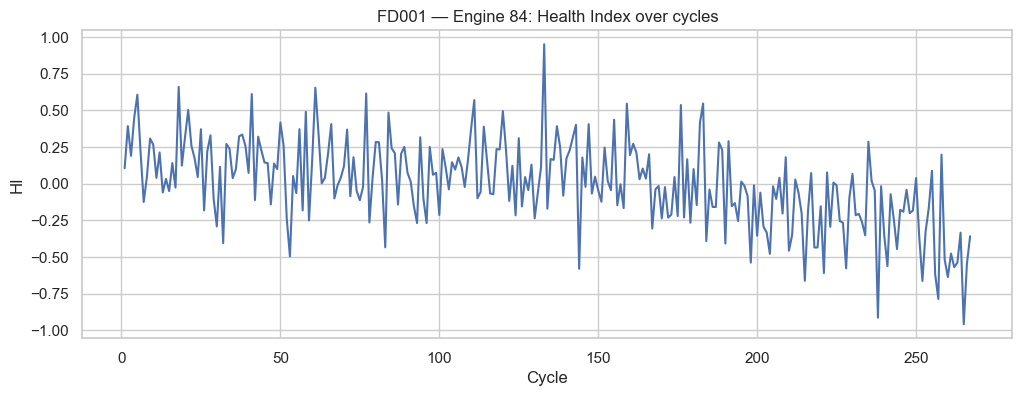

In [37]:
HI_FEATS = top_features[:5]
train_norm["HI"] = -train_norm[HI_FEATS].mean(axis=1)

df_e = train_norm[train_norm["unit_id"] == eng].sort_values("cycle")

plt.figure(figsize=(12,4))
sns.lineplot(data=df_e, x="cycle", y="HI")
plt.title(f"{FD} — Engine {eng}: Health Index over cycles")
plt.xlabel("Cycle")
plt.ylabel("HI")
plt.show()

# 16) Train vs Test Drift Check (Distribution)

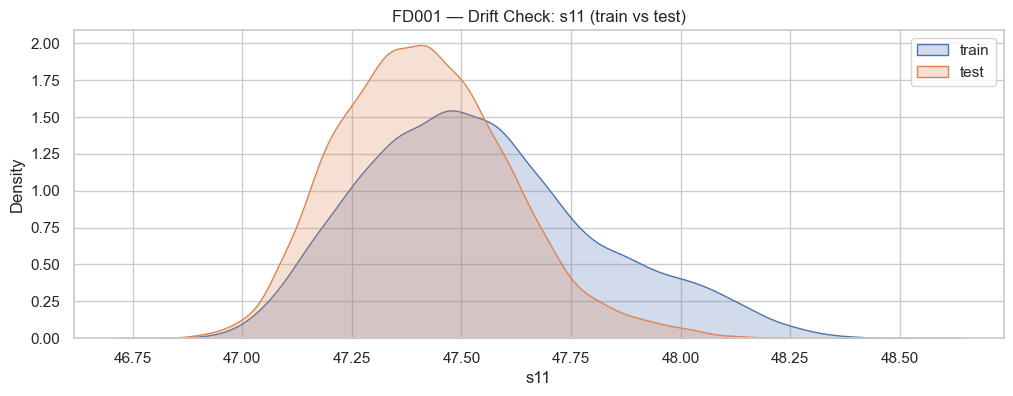

In [38]:
feat = top_features[0]

plt.figure(figsize=(12,4))
sns.kdeplot(train[feat], label="train", fill=True, alpha=0.25)
sns.kdeplot(test[feat],  label="test",  fill=True, alpha=0.25)
plt.title(f"{FD} — Drift Check: {feat} (train vs test)")
plt.xlabel(feat)
plt.legend()
plt.show()

# 17) Full Sensor Overview (Batch Plot across RUL bins)

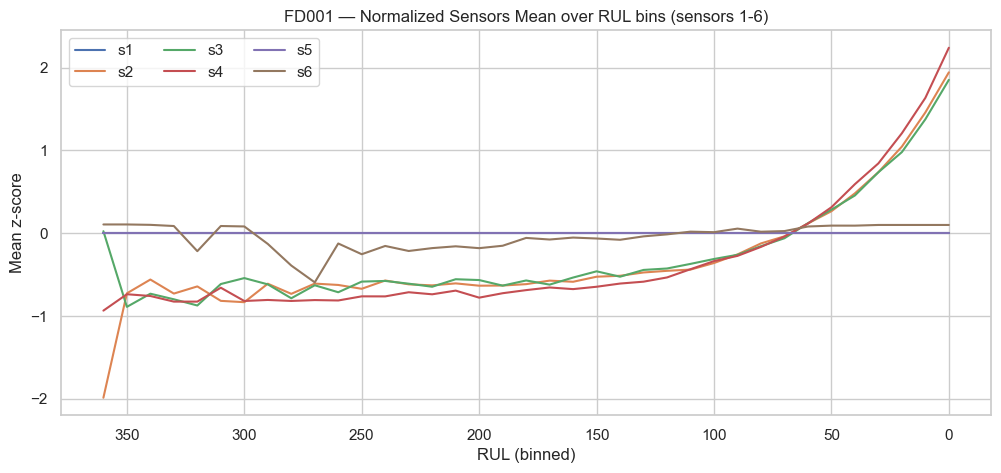

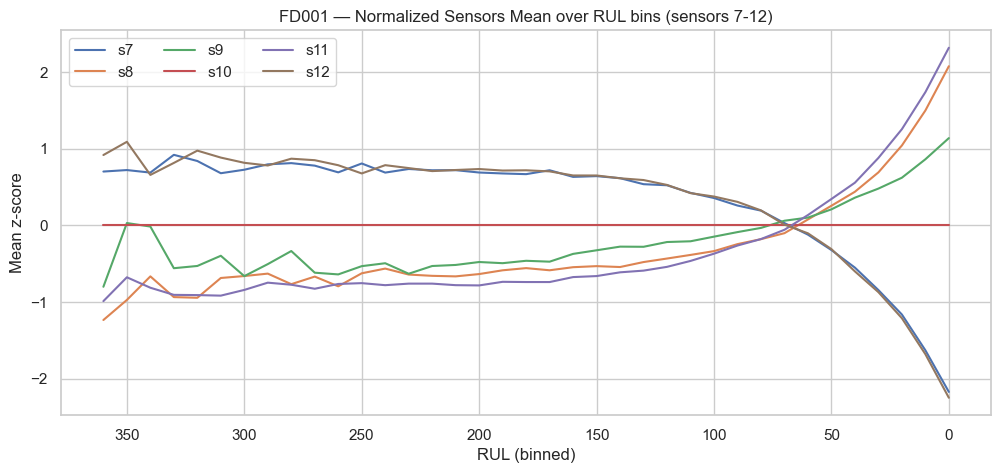

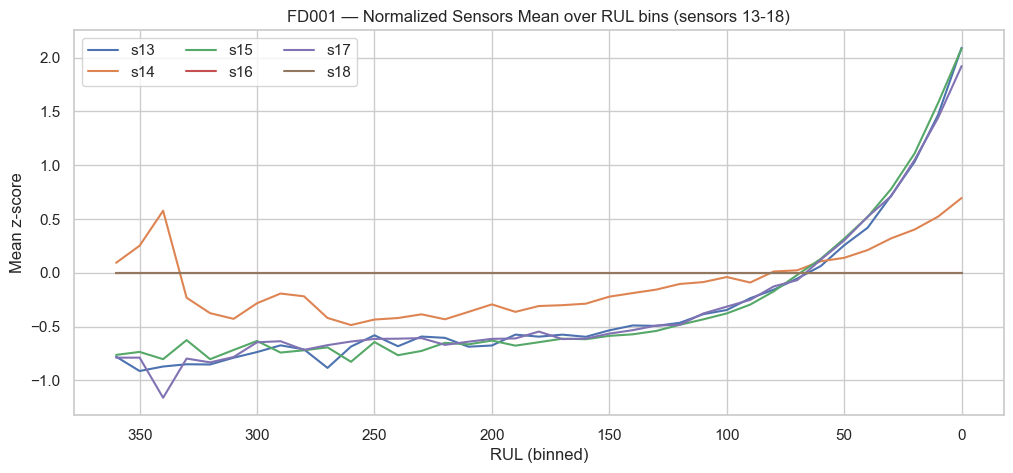

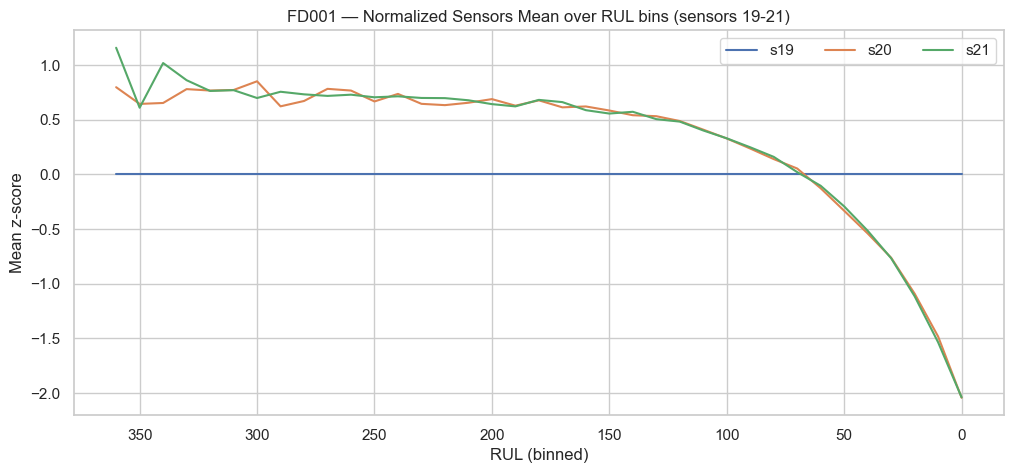

In [39]:
BIN = 10
tmp = train_norm[["RUL"] + sensor_cols].copy()
tmp["RUL_bin"] = (tmp["RUL"] // BIN) * BIN
agg_all = tmp.groupby("RUL_bin")[sensor_cols].mean()

bins = agg_all.index.values
batch = 6

for i in range(0, len(sensor_cols), batch):
    cols_batch = sensor_cols[i:i+batch]
    plt.figure(figsize=(12,5))
    for c in cols_batch:
        plt.plot(bins, agg_all[c], label=c)
    plt.gca().invert_xaxis()
    plt.title(f"{FD} — Normalized Sensors Mean over RUL bins (sensors {i+1}-{min(i+batch, len(sensor_cols))})")
    plt.xlabel("RUL (binned)")
    plt.ylabel("Mean z-score")
    plt.legend(ncol=3)
    plt.show()

# 18) Executive Insights (Auto from Data)

In [40]:
def executive_insights(train_df, corr_series, low_var_sensors, fd_name):
    n_rows = len(train_df)
    n_eng  = train_df["unit_id"].nunique()
    rul_max = train_df["RUL"].max()
    rul_med = train_df["RUL"].median()
    rul_p95 = train_df["RUL"].quantile(0.95)

    # Top correlated sensors
    top = corr_series.abs().sort_values(ascending=False).head(8)

    lines = []
    lines.append(f"## Executive Insights — {fd_name}")
    lines.append(f"- Scale: {n_rows:,} rows across {n_eng} engines.")
    lines.append(f"- RUL distribution (train): max={rul_max:.0f}, median={rul_med:.0f}, p95={rul_p95:.0f}.")

    if len(low_var_sensors) > 0:
        lines.append(f"- Low-variance sensors (candidates to drop): {low_var_sensors}.")
    else:
        lines.append("- No near-zero variance sensors detected under current threshold.")

    lines.append("- Strongest linear signals vs RUL (by |corr|):")
    for k in top.index:
        lines.append(f"  - {k}: corr={corr_series[k]:+.3f}")

    return "\n".join(lines)

# 19) Final Clean Feature Set (Ready for Modeling)

In [41]:
final_sensors = [c for c in sensor_cols if c not in low_var_sensors]
final_features = op_cols + final_sensors

train_final = train_norm[["unit_id", "cycle", "RUL"] + final_features].copy()
test_final  = test_norm[["unit_id", "cycle", "RUL"] + final_features].copy()

print("train_final:", train_final.shape, "test_final:", test_final.shape)
display(train_final.head())

train_final: (20631, 21) test_final: (13096, 21)


,unit_id,cycle,RUL,op_setting_1,op_setting_2,op_setting_3,s2,s3,s4,s6,...,s8,s9,s11,s12,s13,s14,s15,s17,s20,s21
0,1,1,191,-0.261557,-1.588612,0.0,-1.645541,0.037237,-0.777777,0.0,...,-0.708756,-0.422617,-0.164200,0.267725,-1.180265,1.744784,-0.499777,-0.578837,1.317066,1.072205
1,1,2,190,1.069424,-1.234357,0.0,-0.967638,0.405307,-0.481242,0.0,...,-0.990790,-0.854226,-0.089670,1.095300,-0.530578,0.463131,-0.139333,-0.578837,0.957781,1.115972
2,1,3,189,-2.104454,0.891173,0.0,-0.556788,-0.259649,-0.357492,0.0,...,-0.426723,0.951610,-0.909507,1.282172,-1.050327,0.775905,-0.549594,-1.934162,0.658377,0.360510
3,1,4,188,0.455125,-0.171592,0.0,-0.556788,-1.162462,-0.629510,0.0,...,-0.003672,0.247191,-1.431221,1.869484,-0.400640,0.883758,-2.003091,-0.578837,0.239211,0.643095
4,1,5,187,-0.875856,-0.880102,0.0,-0.515703,-1.152045,-0.121665,0.0,...,-0.708756,1.401542,-0.872241,0.975168,-0.920390,0.878365,-0.209664,0.098826,0.358973,0.933291
